# 12.5.1 从局部状态到密度

## 学习目标与先修知识

构造密度与两点相关（two-point correlation）量，检验平均场闭合（mean-field closure）假设。

先修：12.1 二值局部规则；5.2 期望（expectation）与相关；11.1 节点位置语义。

## 具体问题

两条元胞排列都有一半格子为1，但一条交错、另一条成团。只报总体密度能否预测下轮异或规则的激活比例？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

比较 [1,0,1,0] 与 [1,1,0,0]，先数共同的密度和隔一格两侧同时为1的比例。

In [2]:
for state in [[1,0,1,0],[1,1,0,0]]:
    p=sum(state)/len(state)
    c2=sum(state[(i-1)%len(state)]*state[(i+1)%len(state)] for i in range(len(state)))/len(state)
    print(state,'密度与两点相关',p,c2)

[1, 0, 1, 0] 密度与两点相关 0.5 0.5
[1, 1, 0, 0] 密度与两点相关 0.5 0.0


## 模型假设

使用 12.1 的周期、同步、左右邻居异或规则；位置有环形邻域意义。定义宏观密度 p 和隔一格邻居同为1的比例 c2；不是把所有空间相关浓缩为唯一指标。

## 数学解释与推导

二值 $L,R$ 的异或为 $L+R-2LR$。对周期环逐格平均，左右边际平均各为 $p$，所以精确下一步密度 $p'=2p-2c_2$，其中 $c_2=n^{-1}\sum_i x_{i-1}x_{i+1}$。仅知 $p$ 不足以确定 $c_2$；若额外假设两侧独立，才可令 $c_2\approx p^2$，得平均场预测 $2p(1-p)$。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def ca_step(state, boundary, mode, order):
    """Binary rule 90: the next bit is the XOR of its two old/current neighbors."""
    n = len(state)
    result = list(state)

    def neighbor(values, index):
        if boundary == 'periodic':
            return values[index % n]
        return values[index] if 0 <= index < n else 0

    if mode == 'sync':
        old = list(state)
        return [neighbor(old, i - 1) ^ neighbor(old, i + 1) for i in range(n)]
    for i in order:
        result[i] = neighbor(result, i - 1) ^ neighbor(result, i + 1)
    return result


def ca_features(state):
    """Density and distance-two pair fraction for periodic binary cells."""
    n = len(state)
    density = sum(state) / n
    pair_two = sum(state[(i - 1) % n] * state[(i + 1) % n] for i in range(n)) / n
    return [density, pair_two]


def ca_density_predictions(state):
    """Mean-field independence vs exact closure with one pair statistic."""
    density, pair_two = ca_features(state)
    return [2 * density * (1 - density), 2 * density - 2 * pair_two]

## 对照实验

对相同密度的两种排列画出初态和一步后状态（state），比较独立邻居预测与保留相关量的精确值。

交错 p,c2= [0.5, 0.5] 平均场/精确预测= [0.5, 0.0] 实际下一步= 0.0
成团 p,c2= [0.5, 0.0] 平均场/精确预测= [0.5, 1.0] 实际下一步= 1.0


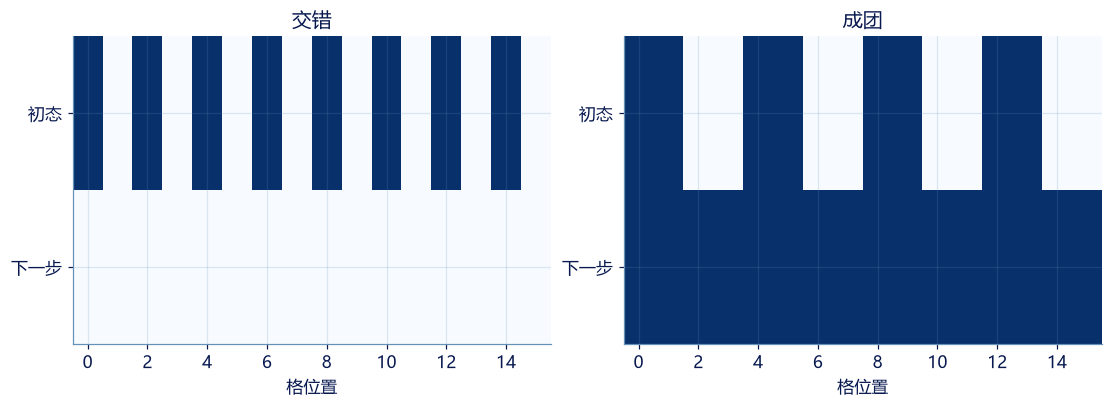

In [4]:
states={'交错':[1,0,1,0]*4,'成团':[1,1,0,0]*4}
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,(name,state) in zip(axes,states.items()):
    next_state=ca_step(state,'periodic','sync',list(range(len(state))))
    ax.imshow([state,next_state],aspect='auto',interpolation='nearest',cmap='Blues',vmin=0,vmax=1)
    ax.set(xlabel='格位置',yticks=[0,1],yticklabels=['初态','下一步'],title=name)
    print(name,'p,c2=',ca_features(state),'平均场/精确预测=',ca_density_predictions(state),
          '实际下一步=',sum(next_state)/len(state))
plt.show()

## 结果解释

两排列的全局密度相同，下一步却可分别为全0或全1。此处独立近似预测都为0.5，遗漏的正是两侧邻居同为1的频率；这一差异与异或规则中的两点相关项相符。

### 独立核对

独立用实际同步更新（synchronous update）值核对两种预测，验证同 p 不同 c2。

In [5]:
features=[ca_features(v) for v in states.values()]
assert all(abs(row[0]-.5)<1e-12 for row in features)
assert len({row[1] for row in features})==2
for state in states.values():
    actual=sum(ca_step(state,'periodic','sync',list(range(len(state)))))/len(state)
    np.testing.assert_allclose(ca_density_predictions(state)[1],actual)
print('局部恒等式、同密度不同相关的反例通过。')

局部恒等式、同密度不同相关的反例通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：密度与隔一格两点相关

采用周期边界（periodic boundary）的二值格状态（state） state。返回类型1密度 p 和距离2的一对位置同时为1的比例 c2=(1/n)Σ_i state[i−1]·state[i+1]；用周期下标。这个相关量决定异或规则下一步密度。

**函数与代码模板**

```python
def solve(
    state: list[int],
) -> tuple[float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 长度至少3的周期二值状态。 | 类别 |

**返回值**

按以下顺序返回元组：(density, pair_two)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `density` | `float` | 当前为1的比例。 | 1 |
| `pair_two` | `float` | 两侧邻居同时为1的比例。 | 1 |

**计算规则**

两个指标都除以 n；c2 取左右两格而不是中心格。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 长度至少3的周期二值状态。 | [1, 0, 1, 0] | 类别 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 0, 1, 0]

result = solve(state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| density | 当前为1的比例。 | 0.5 | 1 |
| pair_two | 两侧邻居同时为1的比例。 | 0.5 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5, 0.5)
```

**样例解释**

同样密度可以配合不同的两点相关（two-point correlation），从而改变局部规则的聚合结果。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：密度与隔一格两点相关](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-periodic-ca-features)

### 第 2 题 · 单项选择题：只看密度遗漏什么

两组周期格的1占比都为1/2，但间隔2的1—1对比例不同。哪个说法成立？

- **A.** 只保留密度会丢失这种空间相关。
- **B.** 密度相同强制每个局部邻域相同。
- **C.** 两组下一步密度必相同。
- **D.** 相关性只由画布宽度决定。

[作答：只看密度遗漏什么](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-same-density)

### 第 3 题 · 单项选择题：局部异或的聚合

左右邻格旧值为 L、R∈{0,1}。L XOR R 等于什么？

- **A.** L+R−2LR。
- **B.** LR。
- **C.** L+R。
- **D.** 1−L−R。

[作答：局部异或的聚合](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-xor-density-identity)

### 第 4 题 · 多项选择题：宏观量先声明尺度

统计一组元胞实验的密度时，哪些约定需要保持一致？

- **A.** 分母包含哪些格子与记录时刻。
- **B.** 是否从同一边界和更新规则取样。
- **C.** 网页背景色。
- **D.** 读取图像像素而不核对状态（state）。

[作答：宏观量先声明尺度](http://127.0.0.1:8000/chapters/12-05-%E4%BB%8E%E5%B1%80%E9%83%A8%E8%A7%84%E5%88%99%E5%88%B0%E5%AE%8F%E8%A7%82%E6%8F%8F%E8%BF%B0/practice/?question=p12-measurement-scale)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供跨尺度主题；本节闭合式从当前二值规则直接推导。